#  Training models for building segmentation

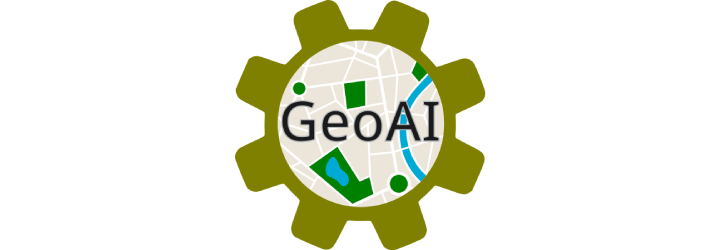

The GeoAI library is a powerful Python package that integrates Artificial Intelligence with geospatial data analysis and visualization. Designed to facilitate the processing, analysis, and visualization of data such as satellite imagery, LiDAR point clouds, and vector data, GeoAI offers intuitive interfaces for applying advanced machine learning models. Its key features include interactive geospatial data visualization, data preparation and processing tools, image segmentation with integration with Meta's Segment Anything Model (SAM), image classification with pre-trained models, and additional capabilities such as terrain analysis and object detection in aerial and satellite imagery.

Let's install the necessary libraries and then import them.

In [ ]:
!pip install geoai-py

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.2/537.2 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 105.3 MB/s eta 0:00:00
   ━━━━

In [ ]:
!pip install ipysheet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 57.7 MB/s eta 0:00:00


In [ ]:
import geoai

In [ ]:
import leafmap
from geoai.download import (
    download_naip,
    download_overture_buildings,
    extract_building_stats,
)
import geopandas as gpd

Let's create an interactive map for visualization:

In [ ]:
m = leafmap.Map(center=[47.6526, -117.5923], zoom=16)
m.add_basemap("Google Satellite")
m

Map(center=[47.6526, -117.5923], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

We will use the polygon of our Area of Interest to delimit the image that we will use in training the model:

In [ ]:
aoi = gpd.read_file('/content/AOI.shp')

In [ ]:
bbox = tuple(aoi.total_bounds)
bbox

(np.float64(-115.22489326840497),
 np.float64(36.275338703201044),
 np.float64(-115.17094561001741),
 np.float64(36.3280462156206))

In [ ]:
downloaded_files = download_naip(
    bbox=bbox,
    output_dir="naip_data",
    max_items=3,
    # year=2020,
)

print(f"Downloaded {len(downloaded_files)} files.")

Found 3 NAIP items.


m_3611547_nw_11_060_20220703.tif: 100%|██████████| 278M/278M [00:03<00:00, 87.0MiB/s]


Successfully saved to naip_data/m_3611547_nw_11_060_20220703.tif


m_3611547_ne_11_060_20220703.tif: 100%|██████████| 275M/275M [00:03<00:00, 82.5MiB/s]


Successfully saved to naip_data/m_3611547_ne_11_060_20220703.tif


m_3611547_sw_11_060_20220611.tif: 100%|██████████| 359M/359M [00:04<00:00, 82.3MiB/s]

Successfully saved to naip_data/m_3611547_sw_11_060_20220611.tif
Downloaded 3 files.


After downloading the images, let's combine them into a single file:

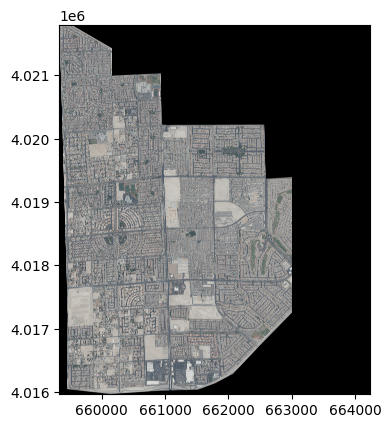

Mosaic created and clipped successfully.


In [ ]:
import rasterio
from rasterio.merge import merge
from rasterio.plot import show
import numpy as np
import matplotlib.pyplot as plt
import os

mosaic_files = []
for file in downloaded_files:
    mosaic_files.append(rasterio.open(file))

mosaic, out_trans = merge(mosaic_files)

out_meta = mosaic_files[0].meta.copy()
out_meta.update(
    {"driver": "GTiff",
     "height": mosaic.shape[1],
     "width": mosaic.shape[2],
     "transform": out_trans,
     "crs": mosaic_files[0].crs}
)

output_mosaic_file = "naip_mosaic.tif"
with rasterio.open(output_mosaic_file, "w", **out_meta) as dest:
    dest.write(mosaic)


with rasterio.open(output_mosaic_file) as src:
    aoi = aoi.to_crs(src.crs)
    out_image, out_transform = rasterio.mask.mask(src, aoi.geometry, crop=True)
    out_image = out_image[0:3]
    out_meta = src.meta

    out_meta.update({"driver": "GTiff",
                     "height": out_image.shape[1],
                     "width": out_image.shape[2],
                     "count": out_image.shape[0],
                     "transform": out_transform})

    with rasterio.open("clipped_naip_mosaic.tif", "w", **out_meta) as dest:
        dest.write(out_image)

with rasterio.open("clipped_naip_mosaic.tif") as src:
    show(src)

print("Mosaic created and clipped successfully.")

Let's get the notes of the built-up areas with the following function:

In [ ]:
data_file = download_overture_buildings(
    bbox=bbox,
    output="buildings.geojson",
)

We can visualize these polygons

In [ ]:
stats = extract_building_stats(data_file)
print(stats)

{'total_buildings': 17067, 'has_height': 12380, 'has_name': 0, 'bbox': [-115.2252597, 36.2748447, -115.1707109, 36.3278606]}


In [ ]:
m = leafmap.Map()
m.add_raster("/content/clipped_naip_mosaic.tif", layer_name="NAIP")
m.add_geojson("/content/buildings.geojson", layer_name="Buildings")
m

Map(center=[36.301361, -115.19817], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…

We will create a folder to receive the image patches and masks:

In [ ]:
os.mkdir('output')

We will use our area of interest to select the polygons that intersect this area:

In [ ]:
gdf = gpd.read_file('/content/buildings.geojson')

<Axes: >

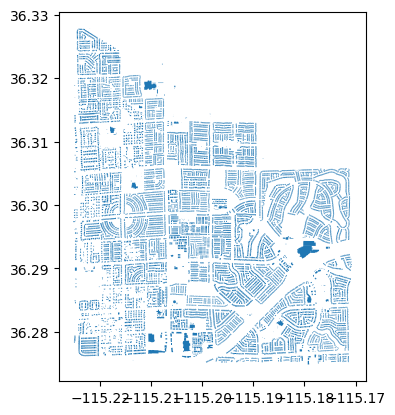

In [ ]:
gdf.plot()

<Axes: >

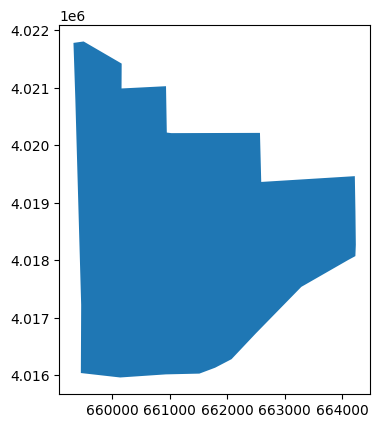

In [ ]:
aoi.plot()

In [ ]:
gdf = gdf.to_crs(aoi.crs)

In [ ]:
gdf = gdf.clip(aoi)

In [ ]:
gdf['class'] = 'building'

In [ ]:
gdf.to_file('buildings.geojson', driver='GeoJSON')

We can now apply the division:

In [ ]:
train_raster_path = 'clipped_naip_mosaic.tif'
train_vector_path = 'buildings.geojson'

In [ ]:
out_folder = "output"
tiles = geoai.export_geotiff_tiles(
    in_raster=train_raster_path,
    out_folder=out_folder,
    in_class_data=train_vector_path,
    tile_size=512,
    stride=256,
    buffer_radius=0,
)


Raster info for clipped_naip_mosaic.tif:
  CRS: EPSG:26911
  Dimensions: 8177 x 9730
  Resolution: (0.6, 0.6)
  Bands: 3
  Bounds: BoundingBox(left=659328.69126, bottom=4015962.3003700003, right=664234.89126, top=4021800.3003700003)
Loaded 14843 features from buildings.geojson
Vector CRS: EPSG:26911
Found 1 unique classes: ['building']


Generated: 1178, With features: 813: 100%|██████████| 1178/1178 [02:31<00:00,  7.77it/s]


------- Export Summary -------
Total tiles exported: 1178
Tiles with features: 813 (69.0%)
Average feature pixels per tile: 56341.1
Output saved to: output

------- Georeference Verification -------


We can see an example:

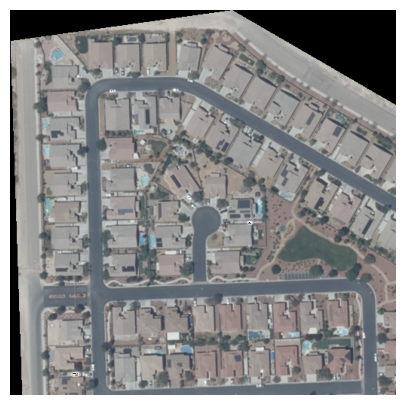

In [ ]:
geoai.view_image("output/images/tile_000000.tif")

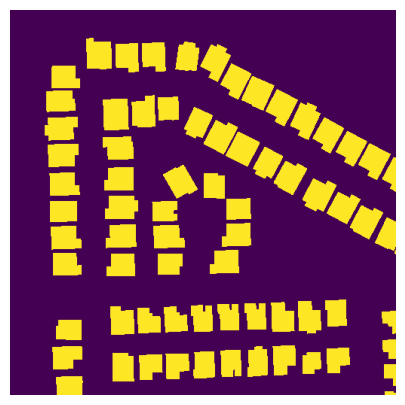

In [ ]:
geoai.view_image("output/labels/tile_000000.tif")

Now we will train MaskRCNN for instance segmentation:

In [ ]:
geoai.train_MaskRCNN_model(
    images_dir=f"{out_folder}/images",
    labels_dir=f"{out_folder}/labels",
    output_dir=f"{out_folder}/models",
    num_channels=3,
    pretrained=True,
    batch_size=4,
    num_epochs=20,
    learning_rate=0.005,
    val_split=0.2,
)

Using device: cuda
Found 1178 image files and 1178 label files
Training on 942 images, validating on 236 images


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth
100%|██████████| 170M/170M [00:00<00:00, 240MB/s]


Epoch: 0, Batch: 0/236, Loss: 5.5559, Time: 3.74s
Epoch: 0, Batch: 10/236, Loss: 2.1915, Time: 9.40s
Epoch: 0, Batch: 20/236, Loss: 1.8480, Time: 9.34s
Epoch: 0, Batch: 30/236, Loss: 1.1009, Time: 9.34s
Epoch: 0, Batch: 40/236, Loss: 1.0270, Time: 9.79s
Epoch: 0, Batch: 50/236, Loss: 0.7898, Time: 9.64s
Epoch: 0, Batch: 60/236, Loss: 0.9136, Time: 10.04s
Epoch: 0, Batch: 70/236, Loss: 0.8309, Time: 10.02s
Epoch: 0, Batch: 80/236, Loss: 0.9991, Time: 10.29s
Epoch: 0, Batch: 90/236, Loss: 0.9434, Time: 10.31s
Epoch: 0, Batch: 100/236, Loss: 1.3411, Time: 10.64s
Epoch: 0, Batch: 110/236, Loss: 1.2331, Time: 10.64s
Epoch: 0, Batch: 120/236, Loss: 0.9133, Time: 10.72s
Epoch: 0, Batch: 130/236, Loss: 0.6541, Time: 10.66s
Epoch: 0, Batch: 140/236, Loss: 0.7277, Time: 10.67s
Epoch: 0, Batch: 150/236, Loss: 0.8144, Time: 10.35s
Epoch: 0, Batch: 160/236, Loss: 0.5955, Time: 10.62s
Epoch: 0, Batch: 170/236, Loss: 1.1481, Time: 10.41s
Epoch: 0, Batch: 180/236, Loss: 0.6189, Time: 10.31s
Epoch: 0, 

Once trained, we will select a test area to make predictions:

In [ ]:
masks_path = "naip_test_prediction.tif"
model_path = f"{out_folder}/models/best_model.pth"

In [ ]:
aoi_pred = gpd.read_file('/content/AOI_pred.shp')

In [ ]:
bbox_pred = tuple(aoi_pred.total_bounds)

In [ ]:
# Download NAIP imagery for the specified region
downloaded_files = download_naip(
    bbox=bbox_pred,
    output_dir="naip_data_pred",
    max_items=3,
    year=2022,
)

print(f"Downloaded {len(downloaded_files)} files.")

Found 1 NAIP items.


m_3611547_sw_11_060_20220611.tif: 100%|██████████| 359M/359M [00:03<00:00, 94.4MiB/s]

Successfully saved to naip_data_pred/m_3611547_sw_11_060_20220611.tif
Downloaded 1 files.


Let's crop our area of interest from the full image:

In [ ]:
raster_pred_path = '/content/naip_data_pred/m_3611547_sw_11_060_20220611.tif'
test_raster_path = 'clipped_naip_pred.tif'

In [ ]:
with rasterio.open(raster_pred_path) as src:
    aoi_pred = aoi_pred.to_crs(src.crs)
    out_image, out_transform = rasterio.mask.mask(src, aoi_pred.geometry, crop=True)
    out_image = out_image[0:3]
    out_meta = src.meta

    out_meta.update({"driver": "GTiff",
                     "height": out_image.shape[1],
                     "width": out_image.shape[2],
                     "count": out_image.shape[0],
                     "transform": out_transform})

    with rasterio.open(test_raster_path, "w", **out_meta) as dest:
        dest.write(out_image)

And apply the model we trained:

In [ ]:
geoai.object_detection(
    test_raster_path,
    masks_path,
    model_path,
    window_size=512,
    overlap=256,
    confidence_threshold=0.5,
    batch_size=4,
    num_channels=3,
)

Processing 80 windows with size 512x512 and overlap 256...


99it [00:15,  6.41it/s]

Inference completed in 15.48 seconds
Saved prediction to naip_test_prediction.tif


We can visualize the result:

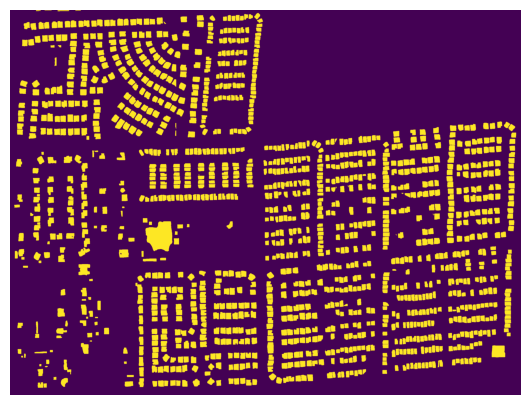

In [ ]:
geoai.view_image(masks_path)

Let's convert the TIFF image to polygons and regularize:

In [ ]:
output_path = "naip_test_prediction.geojson"
gdf = geoai.orthogonalize(masks_path, output_path, epsilon=2)

Processing 1447 features...


Converting features: 100%|██████████| 1447/1447 [00:17<00:00, 83.65shape/s]


Saving to naip_test_prediction.geojson...
Done!


In [ ]:
gdf = geoai.regularize(
    data=output_path,
    simplify_tolerance=2.0,
    allow_45_degree=True,
    diagonal_threshold_reduction=30,
    allow_circles=True,
    circle_threshold=0.9,
)

In [ ]:
vector_url = "regularized_buildings.geojson"
gdf.to_file(vector_url, driver="GeoJSON")

Finally, we present the result in an interactive map:

In [ ]:
m = leafmap.Map()
m.add_raster(test_raster_path)
m.add_gdf(gdf, style={"color": "red", "fillOpacity": 0}, layer_name="Regularized")
legend = {
    "Regularized": "red",
}
m.add_legend(title="Building Footprints", legend_dict=legend)
m

Map(center=[36.2665595, -115.21619150000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom…